In [2]:
#Lasso Regression
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

In [3]:
insurance_data = pd.read_csv("insurance.csv")

In [4]:
# Interaction Features
x = insurance_data.drop(columns = ["charges"])
y = insurance_data["charges"]

x =pd.get_dummies(x, columns = ["region"], drop_first = False, dtype= int)

x["sex"] = x["sex"].map({"female": 1,"male": 0})
x["smoker"] = x["smoker"].map({"yes": 1, "no": 0})

x["age_smoker"] = x["age"]*x["smoker"]
x["bmi_smoker"] = x["bmi"]*x["smoker"]

In [5]:
x_train, x_test,y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42)

Alpha: 0.001, MSE: 20922596.528006196
Alpha: 0.1, MSE: 20921899.28756773
Alpha: 1, MSE: 20915761.347724438
Alpha: 2, MSE: 20909904.88284824
Alpha: 5, MSE: 20894930.88738714
Alpha: 10, MSE: 20879460.42907431
Alpha: 20, MSE: 20885116.38537385
Alpha: 30, MSE: 20939554.097556513
Alpha: 40, MSE: 21030365.003757372
Alpha: 50, MSE: 21137371.396251064
Alpha: 100, MSE: 22325946.521791276


<Axes: >

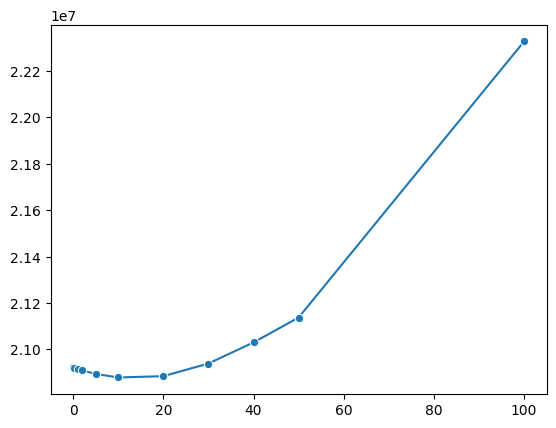

In [6]:
import seaborn as sns

alphas = [0.001, 0.1,1,2,5,10,20, 30, 40, 50, 100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(x_train, y_train)
    
    y_pred = lasso_model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    mses.append(mse)
    print(f"Alpha: {a}, MSE: {mse}")

sns.lineplot(x=alphas, y=mses, marker="o")

In [10]:
from sklearn.linear_model import LassoCV

a = [0.001, 0.1,1,2,5,10,20, 30, 40, 50, 100]

lasso_cv_model = LassoCV(alphas=a, cv=5, max_iter=1000, random_state=42)

lasso_cv_model.fit(x_train, y_train)

print(f"Best alpha: {lasso_cv_model.alpha_}")

y_pred_cv = lasso_cv_model.predict(x_test)
mse_cv = mean_squared_error(y_test, y_pred_cv)
r2 = lasso_cv_model.score(x_test, y_test)
print(f"Cross-validated MSE: {mse_cv}")
print(f"R-squared: {r2}")

Best alpha: 0.001
Cross-validated MSE: 20922596.528006196
R-squared: 0.8652317714485489
